## Data Collection & Cleaning

In [221]:
import ast
import matplotlib.pyplot as plt
import missingno as msno
import plotly.express as px
import pandas as pd

In [194]:
'''
Download the Dataset:

gdown 1VNBTxArDMN2o9fJBDImaON6YUAyJGOU6
unzip lightcast_job_postings.zip
'''
df = pd.read_csv('./data/lightcast_job_postings.csv')

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72476 entries, 0 to 72475
Columns: 131 entries, ID to NAICS_2022_6_NAME
dtypes: bool(2), float64(11), int64(27), object(91)
memory usage: 71.5+ MB


In [196]:
df.dtypes

ID                        object
LAST_UPDATED_DATE         object
LAST_UPDATED_TIMESTAMP    object
DUPLICATES                 int64
POSTED                    object
                           ...  
NAICS_2022_4_NAME         object
NAICS_2022_5               int64
NAICS_2022_5_NAME         object
NAICS_2022_6               int64
NAICS_2022_6_NAME         object
Length: 131, dtype: object

In [197]:
df.head()

,ID,LAST_UPDATED_DATE,LAST_UPDATED_TIMESTAMP,DUPLICATES,POSTED,EXPIRED,DURATION,SOURCE_TYPES,SOURCES,URL,...,NAICS_2022_2,NAICS_2022_2_NAME,NAICS_2022_3,NAICS_2022_3_NAME,NAICS_2022_4,NAICS_2022_4_NAME,NAICS_2022_5,NAICS_2022_5_NAME,NAICS_2022_6,NAICS_2022_6_NAME
0,1f57d95acf4dc67ed2819eb12f049f6a5c11782c,2024-09-06,2024-09-06 20:32:57.352 Z,0,2024-06-02,2024-06-08,6.0,"[\n ""Company""\n]","[\n ""brassring.com""\n]","[\n ""https://sjobs.brassring.com/TGnewUI/Sear...",...,44,Retail Trade,441,Motor Vehicle and Parts Dealers,4413,"Automotive Parts, Accessories, and Tire Retailers",44133,Automotive Parts and Accessories Retailers,441330,Automotive Parts and Accessories Retailers
1,0cb072af26757b6c4ea9464472a50a443af681ac,2024-08-02,2024-08-02 17:08:58.838 Z,0,2024-06-02,2024-08-01,NaN,"[\n ""Job Board""\n]","[\n ""maine.gov""\n]","[\n ""https://joblink.maine.gov/jobs/1085740""\n]",...,56,Administrative and Support and Waste Managemen...,561,Administrative and Support Services,5613,Employment Services,56132,Temporary Help Services,561320,Temporary Help Services
2,85318b12b3331fa490d32ad014379df01855c557,2024-09-06,2024-09-06 20:32:57.352 Z,1,2024-06-02,2024-07-07,35.0,"[\n ""Job Board""\n]","[\n ""dejobs.org""\n]","[\n ""https://dejobs.org/dallas-tx/data-analys...",...,52,Finance and Insurance,524,Insurance Carriers and Related Activities,5242,"Agencies, Brokerages, and Other Insurance Rela...",52429,Other Insurance Related Activities,524291,Claims Adjusting
3,1b5c3941e54a1889ef4f8ae55b401a550708a310,2024-09-06,2024-09-06 20:32:57.352 Z,1,2024-06-02,2024-07-20,48.0,"[\n ""Job Board""\n]","[\n ""disabledperson.com"",\n ""dejobs.org""\n]","[\n ""https://www.disabledperson.com/jobs/5948...",...,52,Finance and Insurance,522,Credit Intermediation and Related Activities,5221,Depository Credit Intermediation,52211,Commercial Banking,522110,Commercial Banking
4,cb5ca25f02bdf25c13edfede7931508bfd9e858f,2024-06-19,2024-06-19 07:00:00.000 Z,0,2024-06-02,2024-06-17,15.0,"[\n ""FreeJobBoard""\n]","[\n ""craigslist.org""\n]","[\n ""https://modesto.craigslist.org/sls/77475...",...,99,Unclassified Industry,999,Unclassified Industry,9999,Unclassified Industry,99999,Unclassified Industry,999999,Unclassified Industry


In [198]:
print(df.columns)

Index(['ID', 'LAST_UPDATED_DATE', 'LAST_UPDATED_TIMESTAMP', 'DUPLICATES',
       'POSTED', 'EXPIRED', 'DURATION', 'SOURCE_TYPES', 'SOURCES', 'URL',
       ...
       'NAICS_2022_2', 'NAICS_2022_2_NAME', 'NAICS_2022_3',
       'NAICS_2022_3_NAME', 'NAICS_2022_4', 'NAICS_2022_4_NAME',
       'NAICS_2022_5', 'NAICS_2022_5_NAME', 'NAICS_2022_6',
       'NAICS_2022_6_NAME'],
      dtype='object', length=131)


In [199]:
#Delete unnecessary columns
columns_to_drop = [
    "ID", "URL", "ACTIVE_URLS", "DUPLICATES", "LAST_UPDATED_TIMESTAMP",
    "NAICS_2022_2", "NAICS_2022_2_NAME",  
    "NAICS_2022_3", "NAICS_2022_3_NAME",
    "NAICS_2022_4", "NAICS_2022_4_NAME",
    "NAICS_2022_5", "NAICS_2022_5_NAME",
    "NAICS_2022_6_NAME", 
    "SOC_2", "SOC_3", "SOC_5" 
]

columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

# convert date columns to datetime format
df['LAST_UPDATED_DATE'] = pd.to_datetime(df['LAST_UPDATED_DATE'])
df['POSTED'] = pd.to_datetime(df['POSTED'])
df['EXPIRED'] = pd.to_datetime(df['EXPIRED'])

# remove internship
df = df[df['IS_INTERNSHIP'] == False]

# remove non-full time jobs
df = df[df['EMPLOYMENT_TYPE_NAME'] == 'Full-time (> 32 hours)']

# remove remote/hybrid jobs, we want to focus on in-person jobs
df = df[df['REMOTE_TYPE_NAME'] == '[None]']

# salary
df['SALARY'] = df['SALARY'].fillna((df['SALARY_FROM'] + df['SALARY_TO']) / 2)  # mean if lower/upper bound avaiable
df['SALARY'] = df['SALARY'].fillna(df['SALARY_FROM'])  # loewr bound if no upper bound presented
df['SALARY'] = df['SALARY'].fillna(df['SALARY_TO'])  # upper bound if no lower bound presented

In [200]:
# Keeping only the latest NAICS_2022_6 and SOC_2021_4 columns

naics_columns = [col for col in df.columns if "NAICS" in col and col != "NAICS_2022_6"]
soc_columns = [col for col in df.columns if "SOC" in col and col != "SOC_2021_4"]
columns_to_drop = naics_columns + soc_columns
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

naics_columns_remaining = [col for col in df.columns if "NAICS" in col]
soc_columns_remaining = [col for col in df.columns if "SOC" in col]

print(" Remaining NAICS columns:", naics_columns_remaining)
print("Remaining SOC columns:", soc_columns_remaining)



 Remaining NAICS columns: ['NAICS_2022_6']
Remaining SOC columns: ['SOC_2021_4']


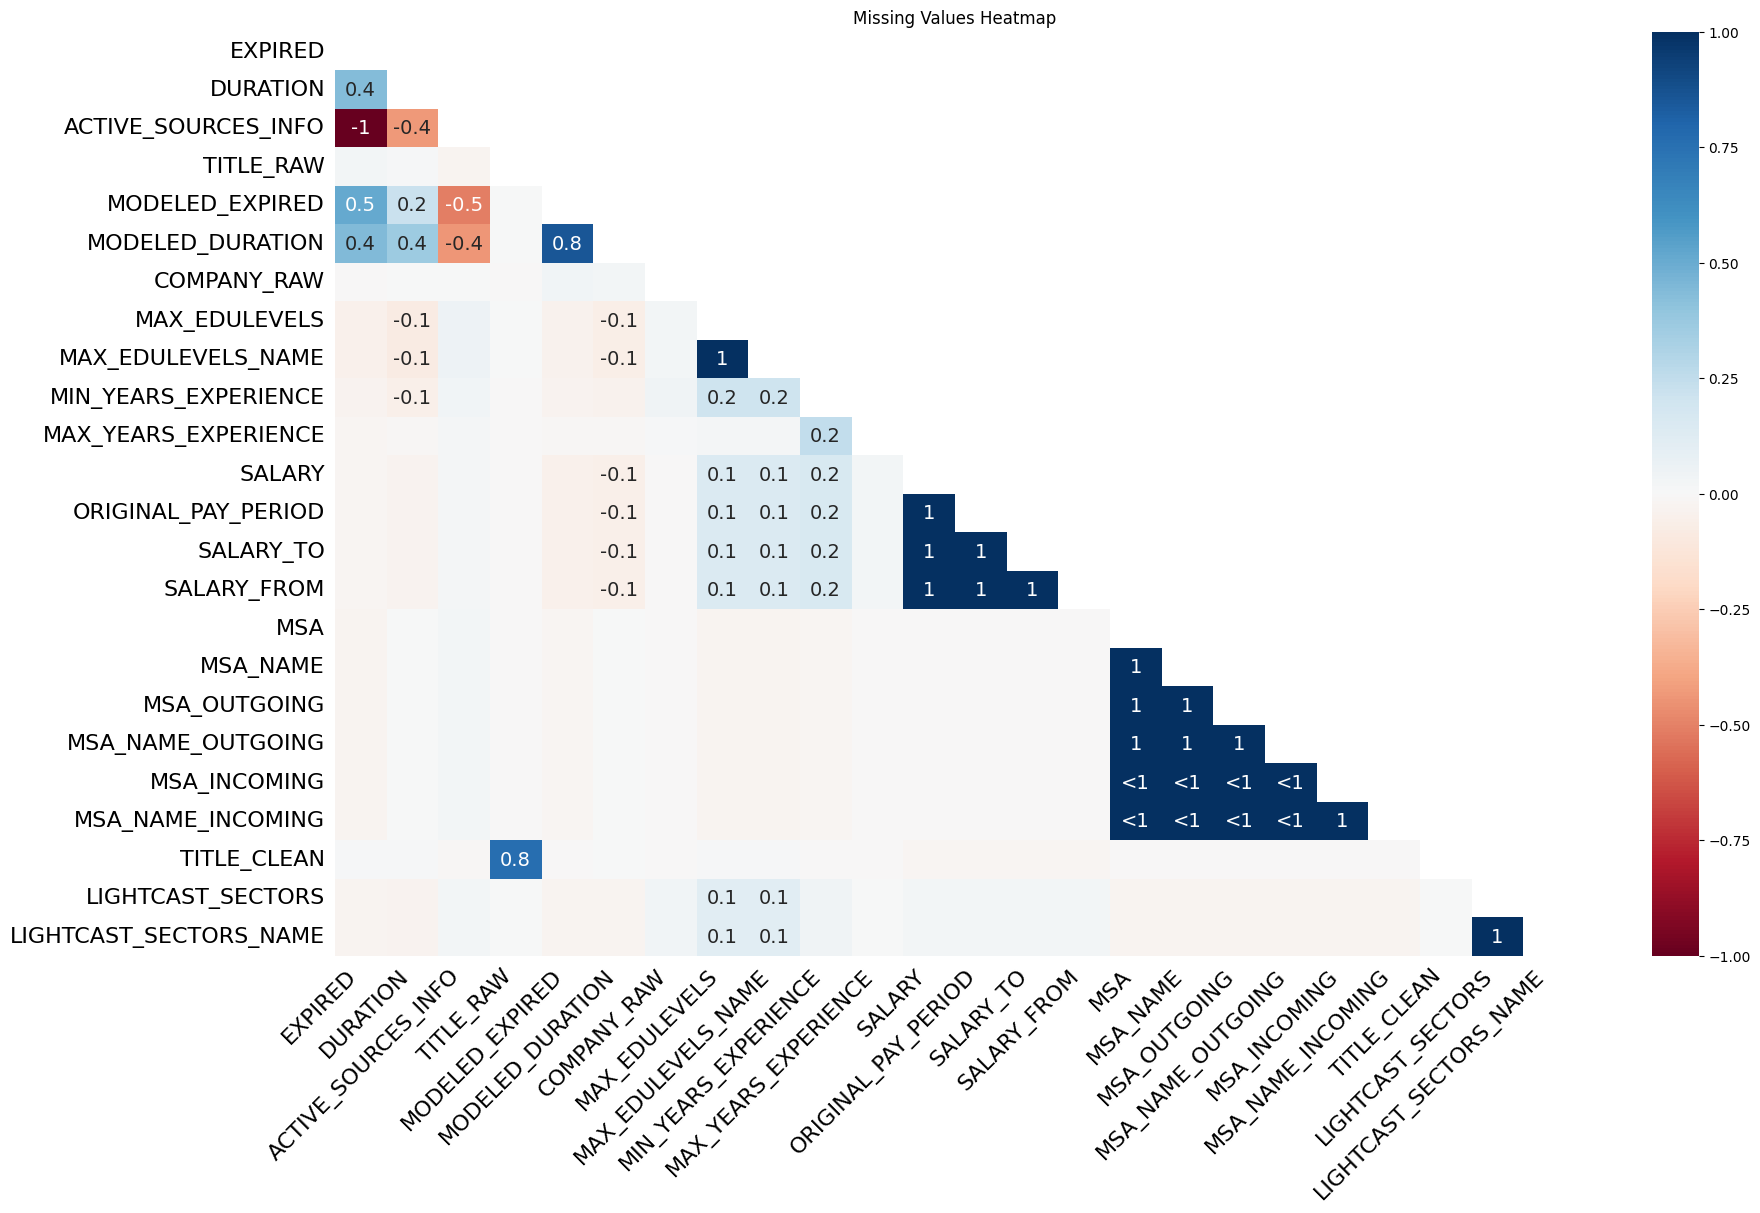

In [201]:
# Visualize missing data
msno.heatmap(df)
plt.title("Missing Values Heatmap")
plt.show()

# Drop columns with >50% missing values
df.dropna(thresh=len(df) * 0.5, axis=1, inplace=True)

In [202]:
## Removing Duplicate Job Postings
df = df.drop_duplicates(subset=["TITLE", "COMPANY", "LOCATION", "POSTED"], keep="first")

In [203]:
df = pd.read_csv("data/cleaned_data.csv")

# identifying ai/non-ai jobs by keyword searching
keywords = ['AI', 'Artificial Intelligence', 'Machine Learning', 'Deep Learning',
            'Data Science', 'Data Analysis', 'Data Analyst', 'Data Analytics',
            'LLM', 'Language Model', 'NLP', 'Natural Language Processing',
            'Computer Vision']

match = lambda col: df[col].str.contains('|'.join(keywords), case=False, na=False)

df['AI_JOB'] = match('TITLE_NAME') \
             | match('SKILLS_NAME') \
             | match('SPECIALIZED_SKILLS_NAME') \
             | match('LIGHTCAST_SECTORS_NAME')

df.to_csv("data/cleaned_data.csv", index=False)

In [204]:
df = pd.read_csv("data/cleaned_data.csv")
df['AI_JOB'].value_counts()
print(df['AI_JOB'].value_counts())


AI_JOB
True     32622
False    20272
Name: count, dtype: int64


In [ ]:
# Read the original data and ensure that the mapping between NAICS_2022_6 and NAICS2_NAME is still present
df_original = pd.read_csv("data/lightcast_job_postings.csv")  # 确保 original_data.csv 包含 NAICS2_NAME

# Create a mapping dictionary
naics_mapping = df_original[['NAICS_2022_6', 'NAICS2_NAME']].drop_duplicates().set_index('NAICS_2022_6')['NAICS2_NAME'].to_dict()

# Read the cleaned data
df_cleaned = pd.read_csv("data/cleaned_data.csv")

# Add the NAICS2 NAME column via NAICS 2022 6
df_cleaned['NAICS2_NAME'] = df_cleaned['NAICS_2022_6'].map(naics_mapping)

# Save the data again
df_cleaned.to_csv("data/cleaned_data.csv", index=False)


## Data Analysis & Visualization

### Q1: AI vs. Non-AI Job Security & Industry Trends

In [211]:
df = pd.read_csv("data/cleaned_data.csv")
if 'NAICS2_NAME' not in df.columns:
    raise KeyError("NAICS2_NAME column is missing. Ensure you created the mapping correctly.")
df_grouped = df.groupby(['AI_JOB', 'NAICS2_NAME']).size().reset_index(name='Job_Count')

fig = px.bar(df_grouped, x='NAICS2_NAME', y='Job_Count', color='AI_JOB',
             title="AI vs. Non-AI Job Distribution Across Industries",
             labels={'NAICS2_NAME': 'Industry', 'Job_Count': 'Number of Jobs'},
             barmode='group')
fig.show()


### Q2: AI-driven Job Growth vs. Job Displacement

In [218]:
df = pd.read_csv("data/cleaned_data.csv")
df_grouped = df.groupby(['POSTED', 'AI_JOB']).size().reset_index(name='Job_Count')

fig = px.line(df_grouped, x='POSTED', y='Job_Count', color='AI_JOB',
              title="AI vs. Non-AI Job Posted Over Time",
              labels={'POSTED': 'Month', 'Job_Count': 'Number of Job Postings'},
              markers=True)

fig.show()

fig.write_html("figures/2_chart.html")

In [219]:
df = pd.read_csv("data/cleaned_data.csv")
df_grouped = df.groupby(['AI_JOB', 'MIN_YEARS_EXPERIENCE']).size().reset_index(name='Job_Count')

fig = px.bar(df_grouped, x='MIN_YEARS_EXPERIENCE', y='Job_Count', color='AI_JOB',
       title="AI vs. Non-AI Jobs by Minimum Years of Experience",
       labels={'MIN_YEARS_EXPERIENCE': 'Min Years of Experience', 'Job_Count': 'Number of Jobs'},
       barmode='group')

fig.show()

fig.write_html("figures/3_chart.html")

In [220]:
df = pd.read_csv("data/cleaned_data.csv")
df_grouped = df[df['SALARY'].notna()].groupby(['AI_JOB', 'MIN_YEARS_EXPERIENCE'])['SALARY'].mean().reset_index()

fig = px.bar(df_grouped, x=['AI_JOB', 'MIN_YEARS_EXPERIENCE'], y='SALARY',
       title="Average Salary: AI vs. Non-AI Jobs",
       labels={'AI_JOB': 'Job Type', 'SALARY': 'Average Salary'},
       color='AI_JOB')

fig.show()

fig.write_html("figures/4_chart.html")

### Q3: AI Careers vs. Traditional Roles

In [222]:
df = pd.read_csv("data/cleaned_data.csv")
df['SKILLS'] = df['SKILLS_NAME'].apply(ast.literal_eval)

ai_skills = df[df['AI_JOB']]['SKILLS'].explode().value_counts().head(20).reset_index()
ai_skills.columns = ['Skill', 'Count']

fig = px.bar(ai_skills, x='Skill', y='Count',
             title="Top AI Job Skills",
             labels={'Skill': 'Skill Name', 'Count': 'Frequency'},
             color='Skill')

fig.show()
fig.write_html("figures/5_chart.html")

traditional_skills = df[~df['AI_JOB']]['SKILLS'].explode().value_counts().head(20).reset_index()
traditional_skills.columns = ['Skill', 'Count']

fig = px.bar(traditional_skills, x='Skill', y='Count',
             title="Top Traditional Job Skills",
             labels={'Skill': 'Skill Name', 'Count': 'Frequency'},
             color='Skill')

fig.show()
fig.write_html("figures/6_chart.html")

### Q4: Emerging AI Job

In [223]:
df = pd.read_csv("data/cleaned_data.csv")
job_title_counts = df[df['AI_JOB']]['TITLE_NAME'].value_counts().head(20).reset_index()
job_title_counts.columns = ['Job_Title', 'Count']

fig = px.bar(job_title_counts, x='Job_Title', y='Count',
             title="Top Emerging AI Job Titles",
             labels={'Job_Title': 'Job Title', 'Count': 'Frequency'},
             color='Job_Title')

fig.show()

fig.write_html("figures/7_chart.html")